In [ ]:
#Reference(s): https://www.kaggle.com/datasets/mdmahfuzsumon/pharma-dataset-drug-classes-interactions-and-cli-pr?resource=download

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

pharma = "pharma_realistic_10000.csv"
#--------------------------------------
df = pd.read_csv(pharma)
#extra for visual analytics
df2 = df.copy()
#Showcases rows and data types
df.dtypes


id                        int64
active_ingredient        object
brand_name               object
manufacturer             object
therapeutic_group        object
pharmacological_class    object
drug_type                object
strength                 object
dosage_form              object
route                    object
indication               object
indication_category      object
side_effects             object
pregnancy_category       object
controlled_substance     object
otc_or_rx                object
food_interaction          int64
alcohol_interaction       int64
num_ingredients           int64
is_combination_drug       int64
dtype: object

In [2]:
#Shape abides by project criteria
df.shape

(10000, 20)

In [3]:
#Checking for any null values before machine model testing
df.isnull().sum()

id                       0
active_ingredient        0
brand_name               0
manufacturer             0
therapeutic_group        0
pharmacological_class    0
drug_type                0
strength                 0
dosage_form              0
route                    0
indication               0
indication_category      0
side_effects             0
pregnancy_category       0
controlled_substance     0
otc_or_rx                0
food_interaction         0
alcohol_interaction      0
num_ingredients          0
is_combination_drug      0
dtype: int64

In [4]:
#Deleted unimportant column
df.drop(columns=['id'], errors='ignore')

,active_ingredient,brand_name,manufacturer,therapeutic_group,pharmacological_class,drug_type,strength,dosage_form,route,indication,indication_category,side_effects,pregnancy_category,controlled_substance,otc_or_rx,food_interaction,alcohol_interaction,num_ingredients,is_combination_drug
0,Amoxicillin + Clavulanate,Augmentin,GSK,Antibiotic,Beta-lactam + Beta-lactamase inhibitor,Small molecule,1000 mg,Syrup,Oral,Infection,Infectious,Nausea,B,No,RX,0,0,2,1
1,Omeprazole,Seclo,AstraZeneca,Antacid,Proton pump inhibitor,Small molecule,10 mg,Capsule,Oral,Peptic ulcer,Gastrointestinal,Headache,C,No,OTC,1,0,1,0
2,Azithromycin,Azit,Incepta,Antibiotic,Macrolide,Small molecule,250 mg,Tablet,Oral,Respiratory infection,Infectious,Abdominal pain,B,No,RX,0,0,1,0
3,Salbutamol,Brodil,GSK,Bronchodilator,Beta-2 agonist,Small molecule,2 mg,Syrup,Oral,COPD,Respiratory,Headache,C,No,RX,0,0,1,0
4,Lisinopril,Listril,AstraZeneca,Antihypertensive,ACE inhibitor,Small molecule,10 mg,Tablet,Oral,Post-MI,Cardiovascular,Hyperkalemia,D,No,RX,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Insulin Glargine,Lantus,Incepta,Antidiabetic,Long-acting insulin,Biologic,300 IU/ml,Injection,Subcutaneous,Type 2 diabetes,Endocrine,Hypoglycemia,C,No,RX,1,1,1,0
9996,Amoxicillin + Clavulanate,Augmentin,GSK,Antibiotic,Beta-lactam + Beta-lactamase inhibitor,Small molecule,375 mg,Tablet,Oral,Infection,Infectious,Nausea,B,No,RX,0,0,2,1
9997,Paracetamol,Panadol,Renata,Analgesic,Para-aminophenol,Small molecule,250 mg/5ml,Tablet,Oral,Pain,General,Nausea,A,No,OTC,0,1,1,0
9998,Ibuprofen,Profen,ACI,Analgesic,NSAID,Small molecule,200 mg,Tablet,Oral,Pain,General,Gastric irritation,D,No,OTC,1,1,1,0


In [13]:
le = LabelEncoder()
y = le.fit_transform(df["therapeutic_group"])
#Setting target & feature values
X = df.drop(columns=["therapeutic_group", "pharmacological_class", "indication_category"])
y = df["therapeutic_group"]

In [14]:

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

#Classifying column types
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

In [15]:
#Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
#Classification report for logistic regression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

lr = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=2000))
])

#Predictions & fitting
lr.fit(X_train, y_train)
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

y_pred_lr = lr.predict(X_test)
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Logistic Regression Classification Report\n-------------------------------------------")
print(f"Train accuracy: {train_acc}")
print(f"Test accuracy: {test_acc}")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Classification Report
-------------------------------------------
Train accuracy: 1.0
Test accuracy: 1.0
                  precision    recall  f1-score   support

       Analgesic       1.00      1.00      1.00       267
         Antacid       1.00      1.00      1.00       154
      Antibiotic       1.00      1.00      1.00       380
  Antidepressant       1.00      1.00      1.00       139
    Antidiabetic       1.00      1.00      1.00       273
   Antihistamine       1.00      1.00      1.00       140
Antihypertensive       1.00      1.00      1.00       389
  Bronchodilator       1.00      1.00      1.00       124
  Lipid-lowering       1.00      1.00      1.00       134

        accuracy                           1.00      2000
       macro avg       1.00      1.00      1.00      2000
    weighted avg       1.00      1.00      1.00      2000



In [17]:
gb = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])
gb.fit(X_train, y_train)

# predictions
y_train_pred = gb.predict(X_train)
y_test_pred = gb.predict(X_test)

# accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Gradient Boosting Classification Report\n-------------------------")
print(f"Train Accuracy: {train_acc}")
print(f"Test Accuracy: {test_acc}")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))


Gradient Boosting Classification Report
-------------------------
Train Accuracy: 1.0
Test Accuracy: 1.0

Classification Report:
                  precision    recall  f1-score   support

       Analgesic       1.00      1.00      1.00       267
         Antacid       1.00      1.00      1.00       154
      Antibiotic       1.00      1.00      1.00       380
  Antidepressant       1.00      1.00      1.00       139
    Antidiabetic       1.00      1.00      1.00       273
   Antihistamine       1.00      1.00      1.00       140
Antihypertensive       1.00      1.00      1.00       389
  Bronchodilator       1.00      1.00      1.00       124
  Lipid-lowering       1.00      1.00      1.00       134

        accuracy                           1.00      2000
       macro avg       1.00      1.00      1.00      2000
    weighted avg       1.00      1.00      1.00      2000



In [6]:
print(df["therapeutic_group"].value_counts())

therapeutic_group
Antibiotic          2034
Antihypertensive    2005
Antidiabetic        1362
Analgesic           1327
Antihistamine        705
Antacid              687
Antidepressant       647
Bronchodilator       620
Lipid-lowering       613
Name: count, dtype: int64


In [7]:
df.groupby(["pharmacological_class", "therapeutic_group"]).size().head(20)

pharmacological_class                   therapeutic_group
ACE inhibitor                           Antihypertensive     683
ARB                                     Antihypertensive     653
Beta-2 agonist                          Bronchodilator       620
Beta-lactam + Beta-lactamase inhibitor  Antibiotic           656
Biguanide                               Antidiabetic         695
Calcium channel blocker                 Antihypertensive     669
Fluoroquinolone                         Antibiotic           725
H1 antagonist                           Antihistamine        705
Long-acting insulin                     Antidiabetic         667
Macrolide                               Antibiotic           653
NSAID                                   Analgesic            664
Para-aminophenol                        Analgesic            663
Proton pump inhibitor                   Antacid              687
SSRI                                    Antidepressant       647
Statin                          

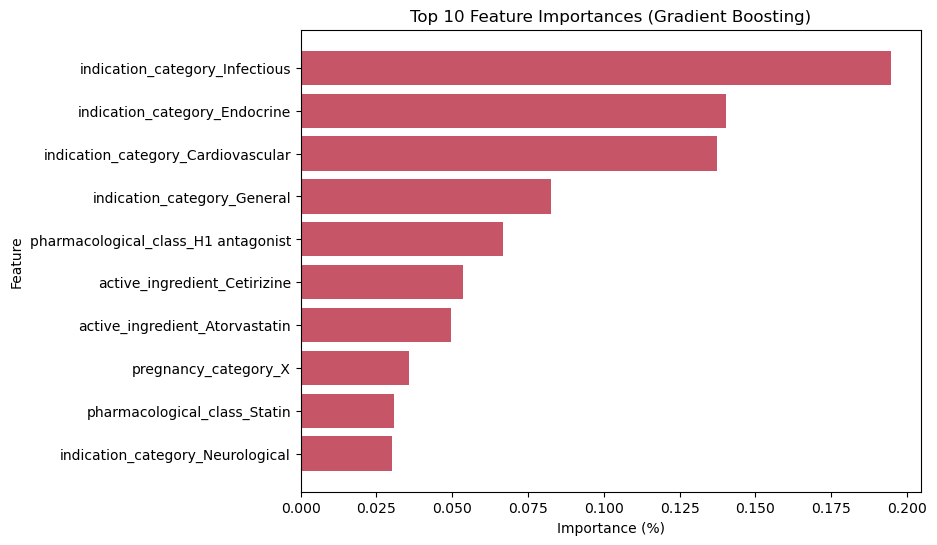

In [56]:
model = gb.named_steps["model"]
import numpy as np
# feature importance from gradient boosting
importances = model.feature_importances_

ohe = gb.named_steps["preprocess"].named_transformers_["cat"]
cat_features = ohe.get_feature_names_out(cat_cols)

features = np.concatenate([cat_features, num_cols])

feat_df = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

#top 8 features only
top_feat_df = feat_df.head(10)

# Plot
plt.figure(figsize=(8,6))
plt.barh(top_feat_df["feature"], top_feat_df["importance"], color="#c65667")
plt.gca().invert_yaxis()
plt.xlabel("Importance (%)")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances (Gradient Boosting)")
plt.show()

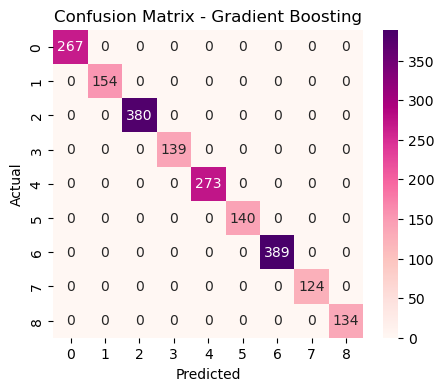

In [54]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)
#Creating confusion matrix to detect class accuracy
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="RdPu")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Gradient Boosting")
plt.show()

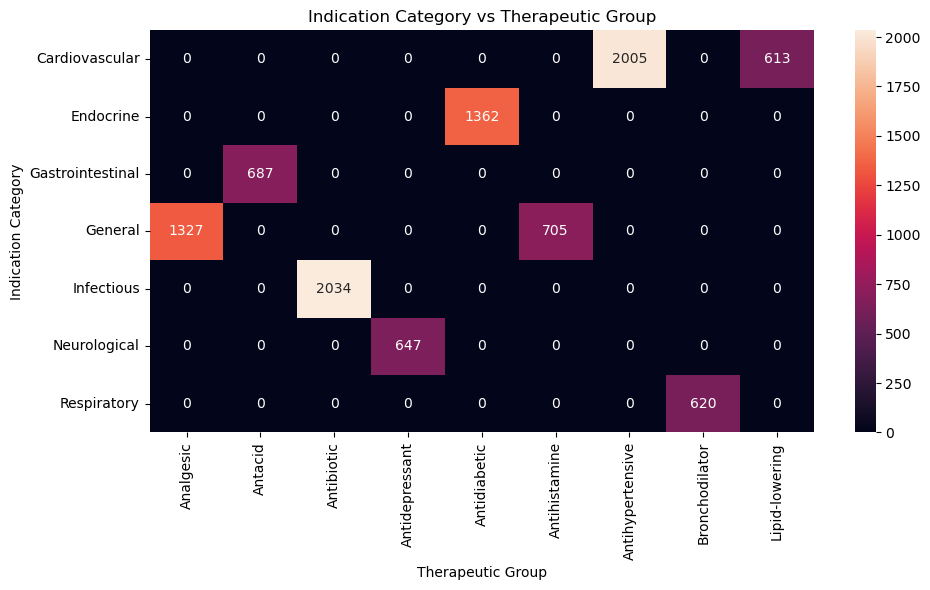

In [88]:
#Heatmap showcases how stringly indication category determines therapeutic group
ct = pd.crosstab(df['indication_category'], df['therapeutic_group'])

plt.figure(figsize=(10, 6))
sns.heatmap(ct, annot=True, fmt="d")

plt.title("Indication Category vs Therapeutic Group")
plt.xlabel("Therapeutic Group")
plt.ylabel("Indication Category")

plt.tight_layout()
plt.show()

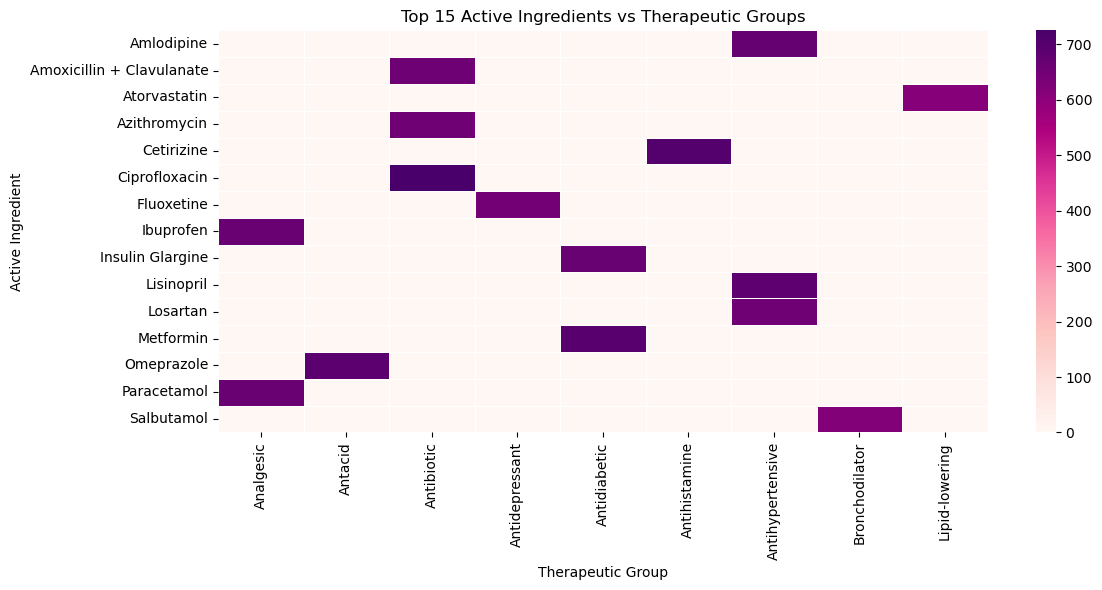

In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#heatmap 
top_ingredients = df["active_ingredient"].value_counts().head(15).index
filtered_df = df[df["active_ingredient"].isin(top_ingredients)]

ct = pd.crosstab(filtered_df["active_ingredient"], filtered_df["therapeutic_group"])

plt.figure(figsize=(12,6))
sns.heatmap(ct, cmap="RdPu", linewidths=0.5)

plt.title("Top 15 Active Ingredients vs Therapeutic Groups")
plt.xlabel("Therapeutic Group")
plt.ylabel("Active Ingredient")

plt.tight_layout()
plt.show()

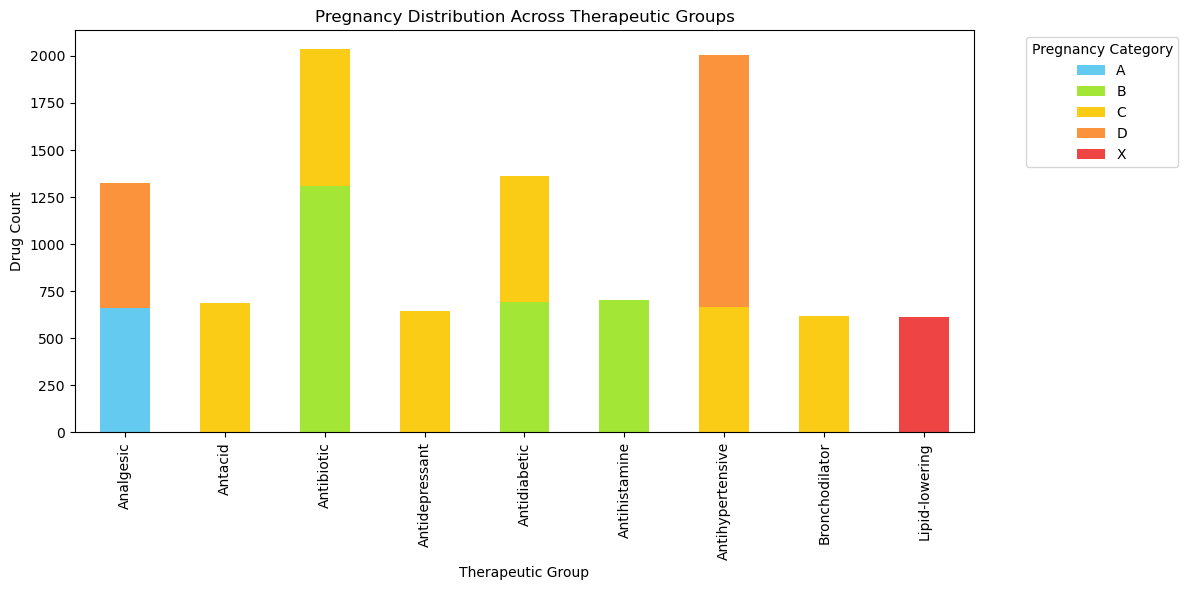

In [21]:
#stacked bar plot indicates pregnancy risk across there
order = ["A", "B", "C", "D", "X"]

ct = pd.crosstab(df["therapeutic_group"], df["pregnancy_category"])[order]
colors = ["#65caef", "#a3e635", "#facc15", "#fb923c", "#ef4444"]
ct.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    color=colors
)
plt.title("Pregnancy Distribution Across Therapeutic Groups")
plt.xlabel("Therapeutic Group")
plt.ylabel("Drug Count")

plt.legend(title="Pregnancy Category", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

C:\Users\firea\AppData\Local\Temp\ipykernel_17612\3108452897.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


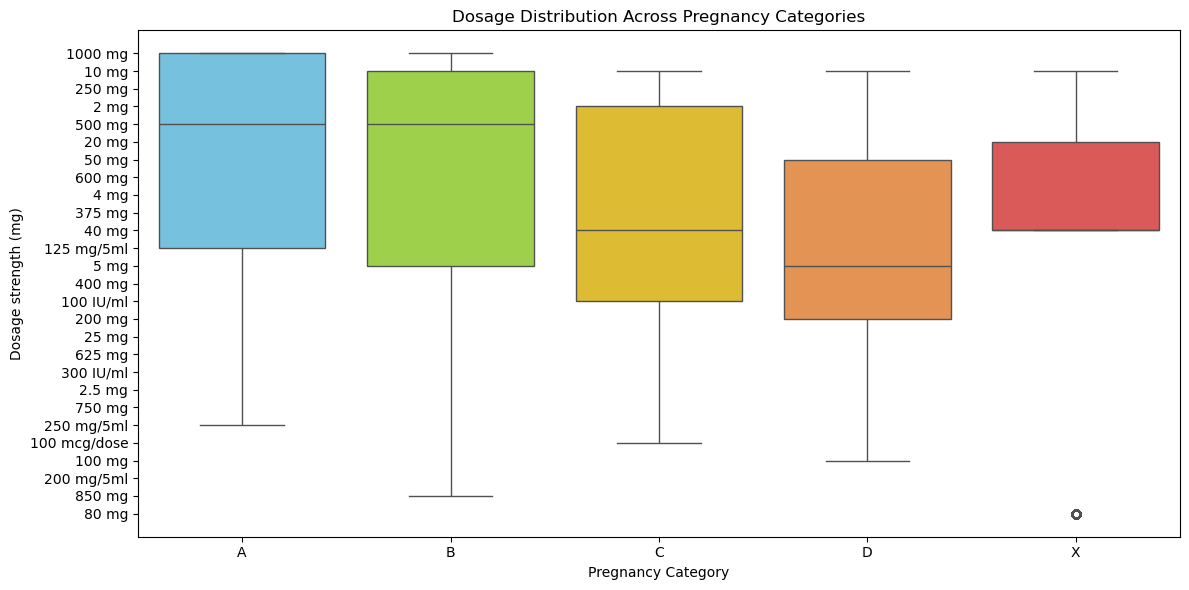

In [25]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x="pregnancy_category",
    y="strength",
    data=df,
    order=order,
    palette=colors
)

plt.title("Dosage Distribution Across Pregnancy Categories")
plt.xlabel("Pregnancy Category")
plt.ylabel("Dosage strength (mg)")

plt.tight_layout()
plt.show()